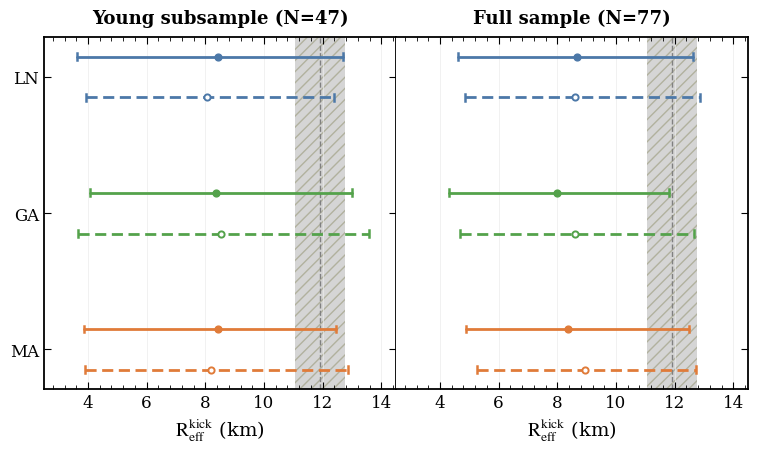

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIX Two Text", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.labelsize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.3,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

# ---------- paths ----------
path_47_ln_fixed = "/home/lz/work/pulsar_kick_period/posterior_young_8param.pkl"
path_47_ln_marg  = "/home/lz/work/pulsar_kick_period/posterior_young_10param.pkl"
path_47_ga_fixed = "/home/lz/work/pulsar_kick_period/posterior_Gamma_47_8param.pkl"
path_47_ga_marg  = "/home/lz/work/pulsar_kick_period/posterior_Gamma_10param.pkl"
path_47_ma_fixed = "/home/lz/work/pulsar_kick_period/posterior_young_7param.pkl"
path_47_ma_marg  = "/home/lz/work/pulsar_kick_period/posterior_young_9param.pkl"

path_77_ln_fixed = "/home/lz/work/pulsar_kick_period/posterior_8param.pkl"
path_77_ln_marg  = "/home/lz/work/pulsar_kick_period/posterior_77_10param.pkl"
path_77_ga_fixed = "/home/lz/work/pulsar_kick_period/posterior_Gamma_8param.pkl"
path_77_ga_marg  = "/home/lz/work/pulsar_kick_period/posterior_Gamma_77_10param.pkl"
path_77_ma_fixed = "/home/lz/work/pulsar_kick_period/posterior_7param.pkl"
path_77_ma_marg  = "/home/lz/work/pulsar_kick_period/posterior_9param.pkl"

def load_r_eff_samples(path, r_name="R_eff"):
    with open(path, "rb") as f:
        data = pickle.load(f)
    cols = data["columns"]
    samples = data["samples"]
    idx = cols.index(r_name)
    return samples[:, idx]

def summary_stats(x):
    q16, q50, q84 = np.percentile(x, [16, 50, 84])
    return q16, q50, q84

def draw_ci(ax, y, q16, q50, q84, color, solid=True, filled=True,
            lw=2.6, cap=0.04, ms=28, z=3):
    ls = '-' if solid else (0, (4, 2))

    ax.plot([q16, q84], [y, y], color=color, lw=lw, ls=ls,
            solid_capstyle='round', zorder=z)

    ax.plot([q16, q16], [y-cap/2, y+cap/2], color=color, lw=lw*0.9, zorder=z)
    ax.plot([q84, q84], [y-cap/2, y+cap/2], color=color, lw=lw*0.9, zorder=z)

    if filled:
        ax.scatter(q50, y, s=24, color=color, edgecolor=color, zorder=z+1)
    else:
        ax.scatter(q50, y, s=20, facecolor='white', edgecolor=color,
                   linewidth=1.4, zorder=z+1)

# ---------- grouped data ----------
young = [
    ("LN", "#4C78A8", path_47_ln_fixed, path_47_ln_marg),
    ("GA", "#54A24B", path_47_ga_fixed, path_47_ga_marg),
    ("MA", "#E07B39", path_47_ma_fixed, path_47_ma_marg),
]

full = [
    ("LN", "#4C78A8", path_77_ln_fixed, path_77_ln_marg),
    ("GA", "#54A24B", path_77_ga_fixed, path_77_ga_marg),
    ("MA", "#E07B39", path_77_ma_fixed, path_77_ma_marg),
]

def collect(group_list):
    out = []
    for label, color, p_fixed, p_marg in group_list:
        q16f, q50f, q84f = summary_stats(load_r_eff_samples(p_fixed))
        q16m, q50m, q84m = summary_stats(load_r_eff_samples(p_marg))
        out.append({
            "label": label,
            "color": color,
            "fixed": (q16f, q50f, q84f),
            "marg":  (q16m, q50m, q84m),
        })
    return out

young_data = collect(young)
full_data = collect(full)

# ---------- plot ----------
fig, axes = plt.subplots(
    1, 2,
    figsize=(8, 6),
    sharex=True,
    sharey=True,
    gridspec_kw={"wspace": 0}
)

panels = [
    (axes[0], young_data, "Young subsample (N=47)"),
    (axes[1], full_data,  "Full sample (N=77)")
]

for ax, data, title in panels:
    ax.axvspan(
    11.05, 12.75,
    facecolor="#757574E8",
    edgecolor="#5F5F21D3",
    alpha=0.3,
    hatch="///",
    linewidth=0.0,
    zorder=0
    #ax.axvspan(8.0, 9.0, color="#D9D4CC", alpha=0.45, zorder=0)
    )
    ax.axvline(x=11.9, color='grey', linestyle='--', linewidth=1, zorder=1)
    ybase = np.array([0.8, 0.4, 0.0], dtype=float)
    off = 0.06

    for i, item in enumerate(data):
        y1 = ybase[i] + off
        y2 = ybase[i] - off
        c = item["color"]

        draw_ci(ax, y1, *item["fixed"], color=c, solid=True, filled=True,
                lw=2, cap=0.02, ms=15)
        draw_ci(ax, y2, *item["marg"], color=c, solid=False, filled=False,
                lw=2, cap=0.02, ms=15)

    ax.set_yticks(ybase)
    ax.set_yticklabels(["LN", "GA", "MA"])
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

    #ax.grid(axis='x', color='0.88', lw=0.8)
    ax.grid(axis='x', color='0.92', lw=0.5)
    ax.set_axisbelow(True)
    ax.set_box_aspect(1)

# x range
for ax in axes:
    ax.set_xlim(2.5, 14.5)

# 外框处理
# 左图：保留四边
axes[0].spines['top'].set_visible(True)
axes[0].spines['right'].set_visible(True)
axes[0].spines['left'].set_visible(True)
axes[0].spines['bottom'].set_visible(True)

# 右图：去掉左边框，让左图右边框作为中间公共边框
axes[1].spines['top'].set_visible(True)
axes[1].spines['right'].set_visible(True)
axes[1].spines['left'].set_visible(False)
axes[1].spines['bottom'].set_visible(True)

# 刻度：中间不要重复
axes[0].set_xticks([4, 6, 8, 10, 12])
axes[1].set_xticks([4, 6, 8, 10, 12, 14])
axes[0].xaxis.set_minor_locator(AutoMinorLocator(5))
axes[1].xaxis.set_minor_locator(AutoMinorLocator(5))
axes[0].set_xlabel(r"$\rm R_{\rm eff}^{\rm kick}$ (km)", fontsize=14)
axes[1].set_xlabel(r"$\rm R_{\rm eff}^{\rm kick}$ (km)", fontsize=14)

# 右图不显示左侧y刻度线，但保留共享位置
axes[1].tick_params(axis='y', left=False, labelleft=False)

handles = [
    Line2D([0], [0], color='0.25', lw=2.6, ls='-', marker='o',
           markersize=5, label='Fixed $M, I$'),
    Line2D([0], [0], color='0.25', lw=1.9, ls=(0, (4, 2)), marker='o',
           markerfacecolor='white', markeredgecolor='0.25',
           markersize=5, label='Marginalized $M, I$')
]
#axes[1].legend(handles=handles, frameon=False, loc='lower center', fontsize=10)

plt.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.16)
#plt.subplots_adjust(left=0.2, right=1, top=0.90, bottom=0.12)
fig.savefig("/home/lz/work/pulsar_kick_period/R_eff_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()